In [1]:
from sklearn import datasets
import numpy as np
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))  # from chapter_2 -> project root
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import pandas as pd
from io import StringIO

In [3]:
csv_data = """A,B,C,D
1.0,2.0,3.0,4.0
5.0,6.0,,8.0
10.0,11.0,12.0,"""

In [4]:
csv_data

'A,B,C,D\n1.0,2.0,3.0,4.0\n5.0,6.0,,8.0\n10.0,11.0,12.0,'

In [5]:
df = pd.read_csv(StringIO(csv_data))
df

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,NaN,8.0
2,10.0,11.0,12.0,NaN


In [6]:
df.isnull().sum()

A    0
B    0
C    1
D    1
dtype: int64

In [7]:
df.values  # np array

array([[ 1.,  2.,  3.,  4.],
       [ 5.,  6., nan,  8.],
       [10., 11., 12., nan]])

In [8]:
df.dropna()

,A,B,C,D
0,1.0,2.0,3.0,4.0


In [9]:
df.dropna(thresh=4)

,A,B,C,D
0,1.0,2.0,3.0,4.0


In [10]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
imputer.fit(df)
imputer.transform(df)


array([[ 1. ,  2. ,  3. ,  4. ],
       [ 5. ,  6. ,  7.5,  8. ],
       [10. , 11. , 12. ,  6. ]])

In [11]:
df.fillna(df.mean())

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,7.5,8.0
2,10.0,11.0,12.0,6.0


### Categorical data

In [12]:
df = pd.DataFrame([
    ["green", "M", 10.1, "class1"],
    ["red", "L", 13.5, "class2"],
    ["blue", "XL", 15.3, "class1"]
])
df.columns = ["color", "size", "price", "classlabel"]
df

,color,size,price,classlabel
0,green,M,10.1,class1
1,red,L,13.5,class2
2,blue,XL,15.3,class1


In [13]:
size_mapping = {
    "XL": 3,
    "L": 2,
    "M": 1
}

In [14]:
df["size"] = df["size"].map(size_mapping)
df

,color,size,price,classlabel
0,green,1,10.1,class1
1,red,2,13.5,class2
2,blue,3,15.3,class1


In [15]:
inverted_size_mapping = {v: k for k, v in size_mapping.items()}
df["size"].map(inverted_size_mapping)

0     M
1     L
2    XL
Name: size, dtype: object

In [16]:
class_mapping = {label: idx for idx, label in enumerate(df["classlabel"].unique())}
class_mapping

{'class1': 0, 'class2': 1}

In [17]:
df["classlabel"] = df["classlabel"].map(class_mapping)
df

,color,size,price,classlabel
0,green,1,10.1,0
1,red,2,13.5,1
2,blue,3,15.3,0


In [18]:
inverted_class_mapping = {v: k for k, v in class_mapping.items()}
df["classlabel"] = df["classlabel"].map(inverted_class_mapping)
df

,color,size,price,classlabel
0,green,1,10.1,class1
1,red,2,13.5,class2
2,blue,3,15.3,class1


In [19]:
from sklearn.preprocessing import LabelEncoder
class_label_encoder = LabelEncoder()
y = class_label_encoder.fit_transform(df["classlabel"])  # same as fit and then transform
y

array([0, 1, 0])

In [20]:
new_class_label_encoder = LabelEncoder()
new_class_label_encoder.fit(df["classlabel"])
y2 = new_class_label_encoder.transform(df["classlabel"])
y2

array([0, 1, 0])

In [21]:
class_label_encoder.inverse_transform(y)

array(['class1', 'class2', 'class1'], dtype=object)

In [22]:
from sklearn.preprocessing import OneHotEncoder
X = df[["color", "size", "price"]].values
X

array([['green', 1, 10.1],
       ['red', 2, 13.5],
       ['blue', 3, 15.3]], dtype=object)

In [23]:
color_ohe = OneHotEncoder()
color_ohe.fit_transform(X[:, 0].reshape(-1, 1)).toarray()

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [24]:
from sklearn.compose import ColumnTransformer
X = df[["color", "size", "price"]].values
column_transformer = ColumnTransformer(
    transformers=[
        ("color_ohe", OneHotEncoder(), [0]),
        ("nothing", "passthrough", [1, 2])
])
column_transformer.fit_transform(X)

array([[0.0, 1.0, 0.0, 1, 10.1],
       [0.0, 0.0, 1.0, 2, 13.5],
       [1.0, 0.0, 0.0, 3, 15.3]], dtype=object)

In [25]:
pd.get_dummies(df[["color", "size", "price"]])

,size,price,color_blue,color_green,color_red
0,1,10.1,False,True,False
1,2,13.5,False,False,True
2,3,15.3,True,False,False


In [26]:
pd.get_dummies(df[["color", "size", "price"]], drop_first=True)

,size,price,color_green,color_red
0,1,10.1,True,False
1,2,13.5,False,True
2,3,15.3,False,False


In [27]:
color_ohe = OneHotEncoder(categories="auto", drop='first')
column_transformer = ColumnTransformer(
    transformers=[
        ("color_ohe", color_ohe, [0]),
        ("nothing", "passthrough", [1, 2])
    ]
)
column_transformer.fit_transform(X).astype(float)

array([[ 1. ,  0. ,  1. , 10.1],
       [ 0. ,  1. ,  2. , 13.5],
       [ 0. ,  0. ,  3. , 15.3]])

In [28]:
df = pd.DataFrame([
    ["green", "M", 10.1, "class1"],
    ["red", "L", 13.5, "class2"],
    ["blue", "XL", 15.3, "class1"]
])
df.columns = ["color", "size", "price", "classlabel"]
df

,color,size,price,classlabel
0,green,M,10.1,class1
1,red,L,13.5,class2
2,blue,XL,15.3,class1


In [29]:
df["x > M"] = df["size"].apply(lambda x: 1 if x in ["L", "XL"] else 0)
df["x > L"] = df["size"].apply(lambda x: 1 if x == "XL" else 0)

In [30]:
del df["size"]
df

,color,price,classlabel,x > M,x > L
0,green,10.1,class1,0,0
1,red,13.5,class2,1,0
2,blue,15.3,class1,1,1


### Wine dataset

In [31]:
df_wine = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data", sep=",")

In [32]:
df_wine.head()

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450


In [33]:
df_wine.columns = [
    "Class label", "Alcohol", "Malic acid", "Ash",
    "Alcalinity of ash", "Magnesium", "Total phenols",
    "Flavanoids", "Nonflavanoid phenols", "Proanthocyanins",
    "Color intensity", "Hue", "OD280/OD315 of diluted wines",
    "Proline"
]
df_wine.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450


In [34]:
np.unique(df_wine["Class label"])

array([1, 2, 3])

In [35]:
from sklearn.model_selection import train_test_split
X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

In [36]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
X_train_norm = mms.fit_transform(X_train)
X_test_norm = mms.transform(X_test)

In [37]:
example = np.array([0, 1, 2, 3, 4, 5])
standardized_example = (example - example.mean()) / example.std()
standardized_example

array([-1.46385011, -0.87831007, -0.29277002,  0.29277002,  0.87831007,
        1.46385011])

In [38]:
normalized_example = (example - example.min()) / (example.max() - example.min())
normalized_example

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

In [39]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

### Regularization

In [42]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', multi_class='ovr')

In [43]:
lr.fit(X_train_std, y_train)

/home/domin/learning/MachineLearningWithPytorch/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/domin/learning/MachineLearningWithPytorch/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'ovr'


In [44]:
print(f"Training accuracy: {lr.score(X_train_std, y_train):.3f}")

print(f"Test accuracy: {lr.score(X_test_std, y_test):.3f}")

Training accuracy: 1.000
Test accuracy: 0.981


In [ ]:
lr.intercept_  # bias

array([-1.27204143, -1.4604908 , -2.24844405])

In [46]:
lr.coef_  # weights

array([[ 1.05144004,  0.30366094,  0.17399459, -0.64358635,  0.        ,
         0.        ,  1.17061745,  0.        ,  0.        ,  0.        ,
         0.        ,  0.69760861,  3.13141729],
       [-1.0837625 , -0.57793459, -0.45572146,  0.08410787, -0.1367652 ,
         0.05500664,  0.57843841,  0.        ,  0.13509178, -1.98742161,
         0.91329371,  0.        , -2.99225347],
       [ 0.16229622,  0.11540839,  0.34199738,  0.        ,  0.        ,
         0.        , -2.55271656,  0.        ,  0.        ,  1.58020312,
        -0.89881472, -0.40165896,  0.        ]])

/home/domin/learning/MachineLearningWithPytorch/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/domin/learning/MachineLearningWithPytorch/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/domin/learning/MachineLearningWithPytorch/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegressi

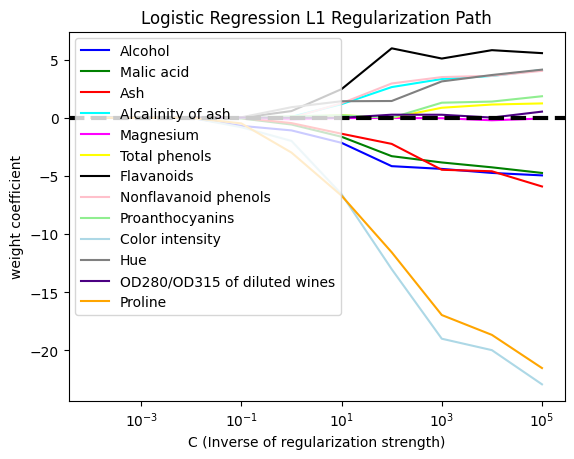

In [50]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = plt.subplot(111)
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black', 'pink', 'lightgreen', 'lightblue', 'gray', 'indigo', 'orange']
weights, params = [], []
for c in np.arange(-4, 6):
    lr = LogisticRegression(penalty='l1', C=10.**c, solver='liblinear', multi_class='ovr')
    lr.fit(X_train_std, y_train)
    weights.append(lr.coef_[1])  # coefficient for class 2
    params.append(10.**c)

weights = np.array(weights)
for column, color in zip(range(weights.shape[1]), colors):
    plt.plot(params, weights[:, column], label=df_wine.columns[column + 1], color=color)
plt.axhline(0, color='black', linestyle='--', linewidth=3)
plt.xscale('log')
plt.xlabel('C (Inverse of regularization strength)')
plt.ylabel('weight coefficient')
plt.title('Logistic Regression L1 Regularization Path')
plt.legend(loc='upper left')
plt.show()

In [ ]:
# 160